# PetFinder.my Adoption Prediction: EDA and Tabular Baseline

Phase 1 covers exploratory data analysis, leak-free tabular preprocessing, and a tabular baseline measured with Quadratic Weighted Kappa.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import get_paths, load_train_data, load_test_data, load_label_tables, modality_counts
from src.features import TabularFeatureBuilder, split_features_target
from src.train import cross_validate_tabular_classifier
from src.utils import ensure_dir, plot_class_distribution, seed_everything

seed_everything(42)
paths = get_paths(root=PROJECT_ROOT)
train_df = load_train_data(paths)
test_df = load_test_data(paths)

print(f"Project root: {PROJECT_ROOT}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(modality_counts(paths))

Project root: C:\Users\andys\Documents\4662_Project
Train shape: (14993, 24)
Test shape: (3972, 23)
{'train_images': 58311, 'test_images': 14465, 'train_metadata': 58311, 'test_metadata': 14465, 'train_sentiment': 14442, 'test_sentiment': 3865}


## Dataset Overview

In [2]:
display(train_df.head())
display(train_df.dtypes.to_frame("dtype"))

missing = pd.DataFrame({
    "missing_count": train_df.isna().sum(),
    "missing_percent": train_df.isna().mean() * 100,
}).sort_values("missing_percent", ascending=False)
display(missing[missing["missing_count"] > 0])

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


,dtype
Type,int64
Name,str
Age,int64
Breed1,int64
Breed2,int64
Gender,int64
Color1,int64
Color2,int64
Color3,int64
MaturitySize,int64


,missing_count,missing_percent
Name,1265,8.437271
Description,13,0.086707


,count,percent
AdoptionSpeed,,
0,410,2.73
1,3090,20.61
2,4037,26.93
3,3259,21.74
4,4197,27.99


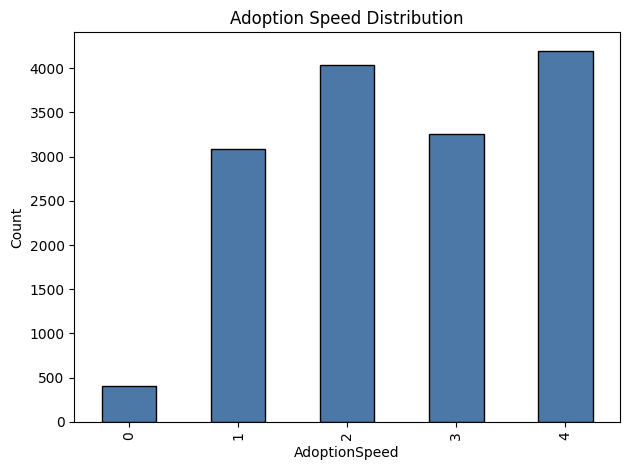

In [3]:
class_counts = train_df["AdoptionSpeed"].value_counts().sort_index()
class_percent = train_df["AdoptionSpeed"].value_counts(normalize=True).sort_index() * 100
display(pd.DataFrame({"count": class_counts, "percent": class_percent.round(2)}))
plot_class_distribution(train_df["AdoptionSpeed"])
plt.show()

In [4]:
label_tables = load_label_tables(paths)
for name, table in label_tables.items():
    print(f"{name}: {table.shape}")
    display(table.head())

breed: (307, 3)


,BreedID,Type,BreedName
0,1,1,Affenpinscher
1,2,1,Afghan Hound
2,3,1,Airedale Terrier
3,4,1,Akbash
4,5,1,Akita


color: (7, 2)


,ColorID,ColorName
0,1,Black
1,2,Brown
2,3,Golden
3,4,Yellow
4,5,Cream


state: (15, 2)


,StateID,StateName
0,41336,Johor
1,41325,Kedah
2,41367,Kelantan
3,41401,Kuala Lumpur
4,41415,Labuan


## Leak-Free Tabular Feature Check

The raw `Name`, `Description`, and `RescuerID` columns are not ordinal-encoded as normal tabular fields here. The reusable feature builder keeps low-leakage metadata features such as description length and missingness flags, while the full description text is reserved for the NLP pipeline.

In [5]:
x, y = split_features_target(train_df)
sample_features = TabularFeatureBuilder().fit_transform(x.head(500), y.head(500))
print(sample_features.shape)
display(sample_features.head())

(500, 28)


,Type,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,...,PhotoAmt,description_length,description_word_count,has_description,has_name,is_mixed_breed,color_count,has_fee,has_video,has_photo
0,1.0,43.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,1.0,...,-0.817388,0.041534,0.073580,0.044766,0.286794,-0.608164,0.044459,2.815772,-0.187608,0.181818
1,1.0,35.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,2.0,...,-0.529778,-0.492036,-0.474989,0.044766,0.286794,-0.608164,0.044459,-0.355142,-0.187608,0.181818
2,0.0,47.0,0.0,0.0,1.0,6.0,0.0,1.0,1.0,0.0,...,0.908273,0.116810,0.073580,0.044766,0.286794,-0.608164,0.044459,-0.355142,-0.187608,0.181818
3,0.0,47.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.195883,-0.430044,-0.451138,0.044766,0.286794,-0.608164,0.044459,2.815772,-0.187608,0.181818
4,0.0,47.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,-0.242168,0.110168,0.216685,0.044766,0.286794,-0.608164,-1.263156,-0.355142,-0.187608,0.181818


## Tabular Baselines

This cell uses XGBoost and LightGBM when installed. If they are missing in the active environment, it runs a scikit-learn histogram gradient boosting sanity baseline instead. The final report should use the XGBoost/LightGBM rows after project dependencies are installed.

In [6]:
models = {}

try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        objective="multi:softmax",
        num_class=5,
        max_depth=6,
        learning_rate=0.05,
        n_estimators=300,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )
except ImportError:
    print("xgboost is not installed; skipping XGBoost baseline.")

try:
    from lightgbm import LGBMClassifier
    models["LightGBM"] = LGBMClassifier(
        objective="multiclass",
        num_class=5,
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
except ImportError:
    print("lightgbm is not installed; skipping LightGBM baseline.")

if not models:
    from sklearn.ensemble import HistGradientBoostingClassifier
    models["HistGradientBoosting sanity check"] = HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        random_state=42,
    )

results = []
raw_results = {}
for model_name, model in models.items():
    print(f"\n{model_name}")
    cv_result = cross_validate_tabular_classifier(model, x, y, n_splits=5, random_state=42)
    raw_results[model_name] = cv_result
    results.append({
        "model": model_name,
        "mean_qwk": cv_result["mean_qwk"],
        "std_qwk": cv_result["std_qwk"],
        "fold_scores": cv_result["fold_scores"],
    })

baseline_results = pd.DataFrame(results).sort_values("mean_qwk", ascending=False)
display(baseline_results)


XGBoost
Fold 1/5 QWK: 0.3384
Fold 2/5 QWK: 0.3835
Fold 3/5 QWK: 0.3773
Fold 4/5 QWK: 0.3356
Fold 5/5 QWK: 0.3943

LightGBM
Fold 1/5 QWK: 0.3258
Fold 2/5 QWK: 0.3730
Fold 3/5 QWK: 0.3667
Fold 4/5 QWK: 0.3395
Fold 5/5 QWK: 0.3790


,model,mean_qwk,std_qwk,fold_scores
0,XGBoost,0.365837,0.024152,"[0.33843316602214313, 0.38354814542873306, 0.3..."
1,LightGBM,0.356783,0.020566,"[0.32577242702720144, 0.373017606903825, 0.366..."


In [7]:
report_dir = ensure_dir(PROJECT_ROOT / "outputs" / "reports")
baseline_results.to_csv(report_dir / "tabular_baseline_cv.csv", index=False)
print(report_dir / "tabular_baseline_cv.csv")

C:\Users\andys\Documents\4662_Project\outputs\reports\tabular_baseline_cv.csv
